In [105]:
import pandas as pd

data = pd.read_csv('data/RNA-Seq-expression-Norilsk2019.csv')

In [106]:
data

,Gene,Species,log_2 fold change,Adjusted p-value
0,ENSG00000181577,homo sapiens,-6.8,6.395631e-214
1,ENSG00000128322,homo sapiens,-6.0,5.979922e-32
2,ENSG00000177606,homo sapiens,5.8,0.000000e+00
3,ENSG00000148600,homo sapiens,-5.8,7.926548e-166
4,ENSG00000164309,homo sapiens,5.6,1.625288e-84
...,...,...,...,...
995,ENSG00000137221,homo sapiens,1.7,5.994751e-72
996,ENSG00000092020,homo sapiens,1.7,3.487785e-71
997,ENSG00000089195,homo sapiens,1.7,8.793077e-71
998,ENSG00000179832,homo sapiens,-1.7,9.521317e-71


In [37]:
import pandas as pd

# Supongamos que ya tienes el DataFrame cargado como `data`

# Clasificar según el log2 fold change
sobre_exp = (data['log_2 fold change'] > 0).sum()   # Mayor a 0 → sobre-expresado
sub_exp = (data['log_2 fold change'] < 0).sum()     # Menor a 0 → sub-expresado
igual_cero = (data['log_2 fold change'] == 0).sum() # Por si hay genes sin cambio

print(f"Genes sobre-expresados: {sobre_exp}")
print(f"Genes sub-expresados: {sub_exp}")
print(f"Genes sin cambio (log2FC = 0): {igual_cero}")


Genes sobre-expresados: 447
Genes sub-expresados: 553
Genes sin cambio (log2FC = 0): 0


In [3]:
# Contar todos los genes
total_genes = len(data)

# Contar genes únicos
genes_unicos = data['Gene'].nunique()

# Calcular cuántos están repetidos
genes_repetidos = total_genes - genes_unicos

print(f"Total de genes: {total_genes}")
print(f"Genes únicos: {genes_unicos}")
print(f"Genes repetidos: {genes_repetidos}")


Total de genes: 1000
Genes únicos: 978
Genes repetidos: 22


In [4]:
# Definir el umbral de significancia
umbral_pvalor = 0.05

# Contar genes no significativos
no_significativos = (data['Adjusted p-value'] > umbral_pvalor).sum()

print(f"Número de genes no significativos (p-ajustado > {umbral_pvalor}): {no_significativos}")


Número de genes no significativos (p-ajustado > 0.05): 0


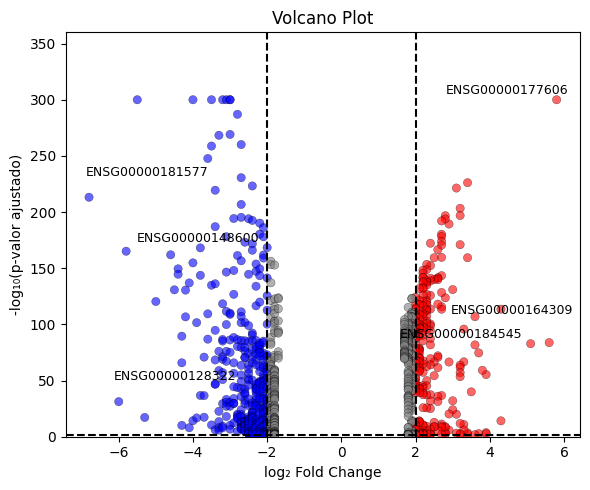

In [116]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from adjustText import adjust_text

# =============================
# Asumiendo que ya tienes tu DataFrame 'data'
# =============================
df = data.copy()

# --- Umbrales definidos ---
fc_threshold = 2  # Solo para colorear
pval_threshold = 0.05

# --- Clasificación (ahora sigue igual para colorear, pero podríamos ignorar p-val si quieres)
df['Significativo'] = 'No significativo'
df.loc[df['log_2 fold change'] >= fc_threshold, 'Significativo'] = 'Sobre-expresado'
df.loc[df['log_2 fold change'] <= -fc_threshold, 'Significativo'] = 'Sub-expresado'

# --- Reemplazo de p-valores 0 ---
eps = 1e-300
df['Adjusted_p_plot'] = df['Adjusted p-value'].replace(0, eps)
df['neglogp'] = -np.log10(df['Adjusted_p_plot'])

# --- Selección top5 SOLO por log2FC ---
top_up = df[df['Significativo'] == 'Sobre-expresado'].nlargest(3, 'log_2 fold change')
top_down = df[df['Significativo'] == 'Sub-expresado'].nsmallest(3, 'log_2 fold change')

# =============================
# Volcano Plot
# =============================
plt.figure(figsize=(6, 5))
ax = sns.scatterplot(
    data=df,
    x='log_2 fold change',
    y='neglogp',
    hue='Significativo',
    palette={'Sobre-expresado': 'red', 'Sub-expresado': 'blue', 'No significativo': 'gray'},
    alpha=0.6,
    edgecolor='black',
    linewidth=0.3
)

# --- Líneas de umbral (solo para referencia visual)
ax.axhline(-np.log10(pval_threshold), ls='--', color='black')
ax.axvline(fc_threshold, ls='--', color='black')
ax.axvline(-fc_threshold, ls='--', color='black')

# --- Etiquetas (solo top log2FC)
texts = []
y_offset = 0.05 * df['neglogp'].max()
for _, row in pd.concat([top_up, top_down]).iterrows():
    x, y = row['log_2 fold change'], row['neglogp']
    label = row.get('symbol', row.get('Gene', ''))
    texts.append(ax.text(x, y + y_offset, label, fontsize=9, ha='center'))

adjust_text(
    texts,
    ax=ax,
    #arrowprops=dict(arrowstyle='-', color='black', lw=0.5),
    #only_move={'points': 'y', 'text': 'y'},
    #force_points=1,
    #force_text=1,
    expand_text=(1, 1)
)

# --- Ajustes finales ---
ax.set_ylim(0, df['neglogp'].max() * 1.2)
ax.set_xlabel('log₂ Fold Change')
ax.set_ylabel('-log₁₀(p‑valor ajustado)')
ax.set_title('Volcano Plot')
#ax.legend(loc='lower left')
ax.get_legend().remove()  # Quita la leyenda del Volcano Plot
plt.tight_layout()
plt.show()


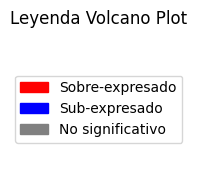

In [55]:
import matplotlib.patches as mpatches

# Definir colores manualmente
legend_patches = [
    mpatches.Patch(color='red', label='Sobre-expresado'),
    mpatches.Patch(color='blue', label='Sub-expresado'),
    mpatches.Patch(color='gray', label='No significativo')
]

# Mostrar leyenda en un gráfico aparte
plt.figure(figsize=(2, 2))
plt.legend(handles=legend_patches, loc='center')
plt.axis('off')
plt.title('Leyenda Volcano Plot')
plt.show()


In [108]:
df

,Gene,Species,log_2 fold change,Adjusted p-value,Significativo,Adjusted_p_plot,neglogp
0,ENSG00000181577,homo sapiens,-6.8,6.395631e-214,Sub-expresado,6.395631e-214,213.194117
1,ENSG00000128322,homo sapiens,-6.0,5.979922e-32,Sub-expresado,5.979922e-32,31.223304
2,ENSG00000177606,homo sapiens,5.8,0.000000e+00,Sobre-expresado,1.000000e-300,300.000000
3,ENSG00000148600,homo sapiens,-5.8,7.926548e-166,Sub-expresado,7.926548e-166,165.100916
4,ENSG00000164309,homo sapiens,5.6,1.625288e-84,Sobre-expresado,1.625288e-84,83.789070
...,...,...,...,...,...,...,...
995,ENSG00000137221,homo sapiens,1.7,5.994751e-72,No significativo,5.994751e-72,71.222229
996,ENSG00000092020,homo sapiens,1.7,3.487785e-71,No significativo,3.487785e-71,70.457450
997,ENSG00000089195,homo sapiens,1.7,8.793077e-71,No significativo,8.793077e-71,70.055859
998,ENSG00000179832,homo sapiens,-1.7,9.521317e-71,No significativo,9.521317e-71,70.021303


In [109]:
# Contar cuántos genes hay en cada categoría
conteo = df['Significativo'].value_counts()
print(conteo)

# Si solo quieres sobre y sub expresados:
sobre = conteo.get('Sobre-expresado', 0)
sub = conteo.get('Sub-expresado', 0)

print(f"Genes sobre-expresados: {sobre}")
print(f"Genes sub-expresados: {sub}")


Significativo
Sub-expresado       391
No significativo    344
Sobre-expresado     265
Name: count, dtype: int64
Genes sobre-expresados: 265
Genes sub-expresados: 391


In [58]:
# --- Concatenar los top genes sobre y sub-expresados ---
top_genes = pd.concat([top_up, top_down])

# --- Mostrar en consola info básica (basado en log2FC) ---
print("Genes etiquetados en el Volcano Plot (basados en log₂FC):")
for idx, row in top_genes.iterrows():
    gene_id = row['Gene'] if 'Gene' in row else row['query']  # por si tienes 'query' en vez de 'Gene'
    nombre = row.get('symbol', gene_id)  # si no hay symbol, usa el ENSG
    fc = row['log_2 fold change']
    pval = row['Adjusted p-value']
    print(f"- {gene_id}  | log2FC: {fc:.3f} | p-adj: {pval:.2e}")


Genes etiquetados en el Volcano Plot (basados en log₂FC):
- ENSG00000177606  | log2FC: 5.800 | p-adj: 0.00e+00
- ENSG00000164309  | log2FC: 5.600 | p-adj: 1.63e-84
- ENSG00000184545  | log2FC: 5.100 | p-adj: 1.51e-83
- ENSG00000181577  | log2FC: -6.800 | p-adj: 6.40e-214
- ENSG00000128322  | log2FC: -6.000 | p-adj: 5.98e-32
- ENSG00000148600  | log2FC: -5.800 | p-adj: 7.93e-166


In [118]:
genes_up

,Gene,Species,log_2 fold change,Adjusted p-value,Significativo,Adjusted_p_plot,neglogp
2,ENSG00000177606,homo sapiens,5.8,0.000000e+00,Sobre-expresado,1.000000e-300,300.000000
4,ENSG00000164309,homo sapiens,5.6,1.625288e-84,Sobre-expresado,1.625288e-84,83.789070
7,ENSG00000184545,homo sapiens,5.1,1.509396e-83,Sobre-expresado,1.509396e-83,82.821197
13,ENSG00000085465,homo sapiens,4.3,2.881886e-114,Sobre-expresado,2.881886e-114,113.540323
16,ENSG00000087589,homo sapiens,4.3,7.197535e-15,Sobre-expresado,7.197535e-15,14.142816
...,...,...,...,...,...,...,...
650,ENSG00000276966,homo sapiens,2.0,8.746922e-03,Sobre-expresado,8.746922e-03,2.058145
651,ENSG00000126787,homo sapiens,2.0,1.026658e-02,Sobre-expresado,1.026658e-02,1.988574
652,ENSG00000064886,homo sapiens,2.0,1.414406e-02,Sobre-expresado,1.414406e-02,1.849426
653,ENSG00000117281,homo sapiens,2.0,1.448692e-02,Sobre-expresado,1.448692e-02,1.839024


In [119]:
# Identificar genes repetidos en 'genes_up'
repeated_genes = genes_up['Gene'][genes_up['Gene'].duplicated(keep=False)].unique()

# Filtrar filas de genes repetidos
repeated_rows = genes_up[genes_up['Gene'].isin(repeated_genes)].copy()

# Mostrar las filas agrupadas por gene para comparar
for gene in repeated_genes:
    gene_data = repeated_rows[repeated_rows['Gene'] == gene]
    print(f"Gene: {gene}")
    print(gene_data[['log_2 fold change', 'Adjusted p-value', 'Significativo', 'Adjusted_p_plot', 'neglogp']])
    print("\n")


Gene: ENSG00000137959
     log_2 fold change  Adjusted p-value    Significativo  Adjusted_p_plot  \
28                 3.9          0.000226  Sobre-expresado         0.000226   
29                 3.9          0.003164  Sobre-expresado         0.003164   
60                 3.4          0.000350  Sobre-expresado         0.000350   
313                2.4          0.008927  Sobre-expresado         0.008927   

      neglogp  
28   3.645778  
29   2.499816  
60   3.456363  
313  2.049296  


Gene: ENSG00000165949
     log_2 fold change  Adjusted p-value    Significativo  Adjusted_p_plot  \
44                 3.6          0.013685  Sobre-expresado         0.013685   
61                 3.4          0.008123  Sobre-expresado         0.008123   
93                 3.2          0.006469  Sobre-expresado         0.006469   
452                2.2          0.010211  Sobre-expresado         0.010211   

      neglogp  
44   1.863758  
61   2.090261  
93   2.189138  
452  1.990931  


Gene: ENSG

In [60]:
fc_threshold

2

In [121]:
import mygene

mg = mygene.MyGeneInfo()

# Filtrar genes sobre-expresados
genes_up = df[(df['log_2 fold change'] >= fc_threshold) & (df['Adjusted p-value'] < pval_threshold)]
gene_ids = genes_up['Gene'].tolist()

# Consulta a MyGene
results = mg.querymany(gene_ids, scopes='ensembl.gene', fields='symbol,name,go', species='human')

# Convertir a DataFrame
go_df = pd.DataFrame(results)

# Filtrar y mostrar columnas relevantes
go_df = go_df[['query', 'symbol', 'name', 'go']]
go_df.head()


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
6 input query terms found dup hits:	[('ENSG00000137959', 4), ('ENSG00000165949', 4), ('ENSG00000137965', 3), ('ENSG00000187608', 2), ('E


,query,symbol,name,go
0,ENSG00000177606,JUN,"Jun proto-oncogene, AP-1 transcription factor ...","{'BP': [{'evidence': 'IDA', 'gocategory': 'BP'..."
1,ENSG00000164309,CMYA5,cardiomyopathy associated 5,"{'CC': [{'evidence': 'IEA', 'gocategory': 'CC'..."
2,ENSG00000184545,DUSP8,dual specificity phosphatase 8,"{'BP': [{'evidence': 'IBA', 'gocategory': 'BP'..."
3,ENSG00000085465,OVGP1,oviductal glycoprotein 1,"{'BP': [{'evidence': 'IEA', 'gocategory': 'BP'..."
4,ENSG00000087589,CASS4,Cas scaffold protein family member 4,"{'BP': [{'evidence': 'IEA', 'gocategory': 'BP'..."


In [122]:
import pandas as pd
import mygene

mg = mygene.MyGeneInfo()

# ===========================
# 1. Filtrar genes sobre-expresados
# ===========================
genes_up = df[(df['log_2 fold change'] >= fc_threshold) & 
              (df['Adjusted p-value'] < pval_threshold)].copy()

gene_ids = genes_up['Gene'].tolist()

# ===========================
# 2. Consulta a MyGene
# ===========================
results = mg.querymany(gene_ids, 
                       scopes='ensembl.gene',   # Cambia a 'symbol' si tus genes son TP53, JUN, etc.
                       fields='symbol,name,go', 
                       species='human')

go_df = pd.DataFrame(results)

# Filtrar columnas relevantes y renombrar 'query' a 'Gene' para facilitar merge
go_df = go_df[['query', 'symbol', 'name', 'go']].rename(columns={'query': 'Gene'})

# ===========================
# 3. Función para extraer términos GO con chequeo de tipo
# ===========================
def extract_terms(go_entry, key):
    if isinstance(go_entry, dict) and key in go_entry:
        items = go_entry[key]
        if isinstance(items, list):
            return "; ".join([f"{item.get('term', 'NA')} ({item.get('id', 'NA')})" for item in items])
    return None

# Aplicar extracción segura a las columnas GO
go_df['Biological_Process'] = go_df['go'].apply(lambda x: extract_terms(x, 'BP'))
go_df['Molecular_Function'] = go_df['go'].apply(lambda x: extract_terms(x, 'MF'))
go_df['Cellular_Component'] = go_df['go'].apply(lambda x: extract_terms(x, 'CC'))

# ===========================
# 4. Agrupar anotaciones GO para tener una sola fila por gen
# ===========================
go_df_grouped = (go_df.groupby('Gene', as_index=False)
                   .agg({
                       'symbol': 'first',
                       'name': 'first',
                       'Biological_Process': lambda x: "; ".join(filter(None, pd.unique(x))),
                       'Molecular_Function': lambda x: "; ".join(filter(None, pd.unique(x))),
                       'Cellular_Component': lambda x: "; ".join(filter(None, pd.unique(x))),
                   }))

# ===========================
# 5. Merge con genes_up manteniendo duplicados en genes_up
# ===========================
final_df = genes_up.merge(go_df_grouped, on='Gene', how='left')

# Opcional: revisar resultados
print(final_df.shape)
print(final_df.head())


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
6 input query terms found dup hits:	[('ENSG00000137959', 4), ('ENSG00000165949', 4), ('ENSG00000137965', 3), ('ENSG00000187608', 2), ('E


(265, 12)
              Gene       Species  log_2 fold change  Adjusted p-value  \
0  ENSG00000177606  homo sapiens                5.8      0.000000e+00   
1  ENSG00000164309  homo sapiens                5.6      1.625288e-84   
2  ENSG00000184545  homo sapiens                5.1      1.509396e-83   
3  ENSG00000085465  homo sapiens                4.3     2.881886e-114   
4  ENSG00000087589  homo sapiens                4.3      7.197535e-15   

     Significativo  Adjusted_p_plot     neglogp symbol  \
0  Sobre-expresado    1.000000e-300  300.000000    JUN   
1  Sobre-expresado     1.625288e-84   83.789070  CMYA5   
2  Sobre-expresado     1.509396e-83   82.821197  DUSP8   
3  Sobre-expresado    2.881886e-114  113.540323  OVGP1   
4  Sobre-expresado     7.197535e-15   14.142816  CASS4   

                                                name  \
0  Jun proto-oncogene, AP-1 transcription factor ...   
1                        cardiomyopathy associated 5   
2                     dual specifi

In [131]:
final_df.head(10)

,Gene,Species,log_2 fold change,Adjusted p-value,Significativo,Adjusted_p_plot,neglogp,symbol,name,Biological_Process,Molecular_Function,Cellular_Component
0,ENSG00000177606,homo sapiens,5.8,0.000000e+00,Sobre-expresado,1.000000e-300,300.000000,JUN,"Jun proto-oncogene, AP-1 transcription factor ...",negative regulation of transcription by RNA po...,transcription cis-regulatory region binding (G...,nuclear chromosome (GO:0000228); chromatin (GO...
1,ENSG00000164309,homo sapiens,5.6,1.625288e-84,Sobre-expresado,1.625288e-84,83.789070,CMYA5,cardiomyopathy associated 5,,,nucleus (GO:0005634); nucleus (GO:0005634); cy...
2,ENSG00000184545,homo sapiens,5.1,1.509396e-83,Sobre-expresado,1.509396e-83,82.821197,DUSP8,dual specificity phosphatase 8,signal transduction (GO:0007165); dephosphoryl...,phosphoprotein phosphatase activity (GO:000472...,nucleus (GO:0005634); cytoplasm (GO:0005737); ...
3,ENSG00000085465,homo sapiens,4.3,2.881886e-114,Sobre-expresado,2.881886e-114,113.540323,OVGP1,oviductal glycoprotein 1,carbohydrate metabolic process (GO:0005975); c...,chitinase activity (GO:0004568); chitin bindin...,extracellular region (GO:0005576); cytosol (GO...
4,ENSG00000087589,homo sapiens,4.3,7.197535e-15,Sobre-expresado,7.197535e-15,14.142816,CASS4,Cas scaffold protein family member 4,cell adhesion (GO:0007155); cell surface recep...,protein binding (GO:0005515); protein tyrosine...,cytoplasm (GO:0005737); cytoplasm (GO:0005737)...
5,ENSG00000180573,homo sapiens,3.9,4.656240e-56,Sobre-expresado,4.656240e-56,55.331965,H2AC6,H2A clustered histone 6,negative regulation of cell population prolife...,DNA binding (GO:0003677); protein binding (GO:...,nucleosome (GO:0000786); nucleosome (GO:000078...
6,ENSG00000137959,homo sapiens,3.9,2.260593e-04,Sobre-expresado,2.260593e-04,3.645778,IFI44L,interferon induced protein 44 like,immune response (GO:0006955); defense response...,,cytoplasm (GO:0005737); cytosol (GO:0005829)
7,ENSG00000137959,homo sapiens,3.9,3.163618e-03,Sobre-expresado,3.163618e-03,2.499816,IFI44L,interferon induced protein 44 like,immune response (GO:0006955); defense response...,,cytoplasm (GO:0005737); cytosol (GO:0005829)
8,ENSG00000151012,homo sapiens,3.8,7.658681e-60,Sobre-expresado,7.658681e-60,59.115846,SLC7A11,solute carrier family 7 member 11,amino acid transmembrane transport (GO:0003333...,protein binding (GO:0005515); L-amino acid tra...,plasma membrane (GO:0005886); plasma membrane ...
9,ENSG00000083635,homo sapiens,3.7,2.420141e-75,Sobre-expresado,2.420141e-75,74.616159,NUFIP1,nuclear FMR1 interacting protein 1,box C/D snoRNP assembly (GO:0000492); box C/D ...,DNA binding (GO:0003677); RNA binding (GO:0003...,fibrillar center (GO:0001650); nucleus (GO:000...


In [124]:
import pandas as pd
import ast

# Asegurarse que la columna 'go' es un diccionario
go_df['go'] = go_df['go'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

bp_terms = []

for _, row in go_df.iterrows():
    go_data = row['go']
    if isinstance(go_data, dict) and 'BP' in go_data:
        for bp in go_data['BP']:
            # Solo agregar si es dict y tiene la clave 'term'
            if isinstance(bp, dict) and 'term' in bp:
                bp_terms.append({
                    'Gene': row['symbol'],
                    'GO_term': bp.get('term'),
                    'Evidence': bp.get('evidence')
                })

bp_df = pd.DataFrame(bp_terms)
print(bp_df.head())


  Gene                                            GO_term Evidence
0  JUN  negative regulation of transcription by RNA po...      IDA
1  JUN  negative regulation of transcription by RNA po...      IMP
2  JUN                                       angiogenesis      IEA
3  JUN                         microglial cell activation      IEA
4  JUN                                  liver development      IEA


In [125]:
top_terms = bp_df['GO_term'].value_counts().head(10)
print(top_terms)


GO_term
positive regulation of transcription by RNA polymerase II    61
regulation of transcription by RNA polymerase II             50
negative regulation of transcription by RNA polymerase II    49
regulation of DNA-templated transcription                    39
defense response to virus                                    32
innate immune response                                       31
positive regulation of DNA-templated transcription           28
apoptotic process                                            27
DNA damage response                                          26
negative regulation of DNA-templated transcription           22
Name: count, dtype: int64


In [ ]:
top_terms

GO_term
positive regulation of transcription by RNA polymerase II    61
regulation of transcription by RNA polymerase II             50
negative regulation of transcription by RNA polymerase II    49
regulation of DNA-templated transcription                    39
defense response to virus                                    32
innate immune response                                       31
positive regulation of DNA-templated transcription           28
apoptotic process                                            27
DNA damage response                                          26
negative regulation of DNA-templated transcription           22
Name: count, dtype: int64

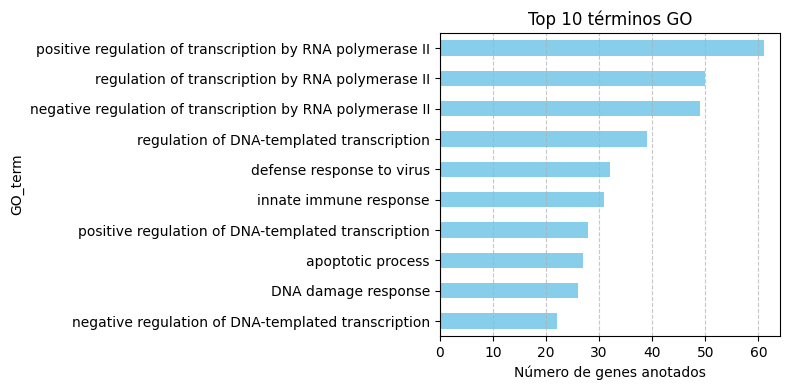

In [64]:
import matplotlib.pyplot as plt

# Ejemplo con conteos de términos GO (puede venir de tu dataframe)
go_counts = bp_df['GO_term'].value_counts().head(10)

plt.figure(figsize=(8,4))
go_counts.sort_values().plot(kind='barh', color='skyblue')
plt.xlabel('Número de genes anotados')
plt.title('Top 10 términos GO')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


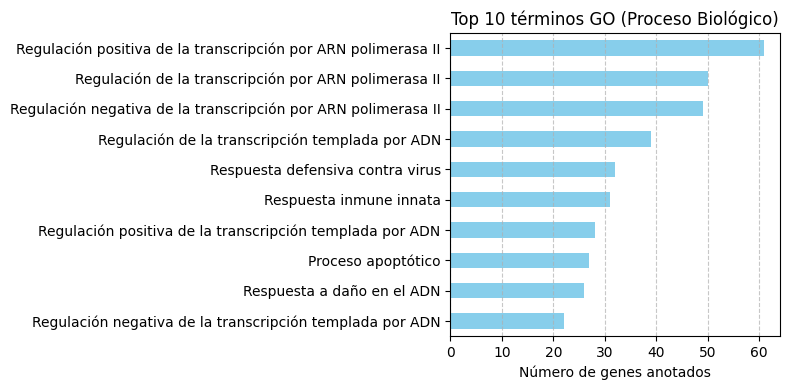

In [144]:
import matplotlib.pyplot as plt
import pandas as pd

# Diccionario con las traducciones manuales de los términos GO
go_counts_es = pd.Series({
    'Regulación positiva de la transcripción por ARN polimerasa II': 61,
    'Regulación de la transcripción por ARN polimerasa II': 50,
    'Regulación negativa de la transcripción por ARN polimerasa II': 49,
    'Regulación de la transcripción templada por ADN': 39,
    'Respuesta defensiva contra virus': 32,
    'Respuesta inmune innata': 31,
    'Regulación positiva de la transcripción templada por ADN': 28,
    'Proceso apoptótico': 27,
    'Respuesta a daño en el ADN': 26,
    'Regulación negativa de la transcripción templada por ADN': 22
})

plt.figure(figsize=(8,4))
go_counts_es.sort_values().plot(kind='barh', color='skyblue')
plt.xlabel('Número de genes anotados')
plt.title('Top 10 términos GO (Proceso Biológico)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [126]:
top_up

,Gene,Species,log_2 fold change,Adjusted p-value,Significativo,Adjusted_p_plot,neglogp
2,ENSG00000177606,homo sapiens,5.8,0.000000e+00,Sobre-expresado,1.000000e-300,300.000000
4,ENSG00000164309,homo sapiens,5.6,1.625288e-84,Sobre-expresado,1.625288e-84,83.789070
7,ENSG00000184545,homo sapiens,5.1,1.509396e-83,Sobre-expresado,1.509396e-83,82.821197


In [ ]:
go_df[0:1]['B']

0    negative regulation of transcription by RNA po...
Name: Biological_Process, dtype: object

In [159]:
# Filtrar por JUN y obtener Biological_Process
jun_bp = go_df.loc[go_df['symbol'] == 'JUN', 'Biological_Process'].values[0]
print(jun_bp)


negative regulation of transcription by RNA polymerase II (GO:0000122); negative regulation of transcription by RNA polymerase II (GO:0000122); angiogenesis (GO:0001525); microglial cell activation (GO:0001774); liver development (GO:0001889); positive regulation of endothelial cell proliferation (GO:0001938); outflow tract morphogenesis (GO:0003151); regulation of DNA-templated transcription (GO:0006355); regulation of DNA-templated transcription (GO:0006355); regulation of transcription by RNA polymerase II (GO:0006357); regulation of transcription by RNA polymerase II (GO:0006357); apoptotic process (GO:0006915); transforming growth factor beta receptor signaling pathway (GO:0007179); JNK cascade (GO:0007254); JNK cascade (GO:0007254); cell population proliferation (GO:0008283); negative regulation of cell population proliferation (GO:0008285); response to xenobiotic stimulus (GO:0009410); positive regulation of epithelial cell migration (GO:0010634); release from viral latency (GO:

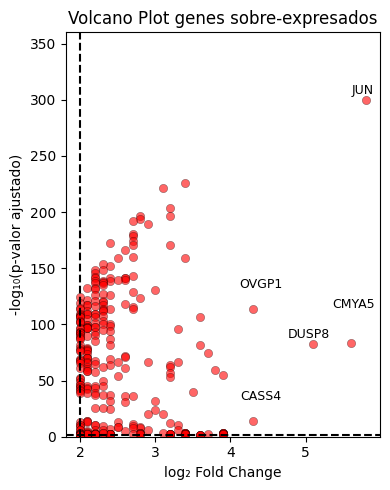

Genes etiquetados en el Volcano Plot (sobre-expresados, top por log₂FC):
- ENSG00000177606 | Jun proto-oncogene, AP-1 transcription factor subunit (JUN) | log2FC: 5.800 | p-adj: 0.00e+00
- ENSG00000164309 | cardiomyopathy associated 5 (CMYA5) | log2FC: 5.600 | p-adj: 1.63e-84
- ENSG00000184545 | dual specificity phosphatase 8 (DUSP8) | log2FC: 5.100 | p-adj: 1.51e-83
- ENSG00000085465 | oviductal glycoprotein 1 (OVGP1) | log2FC: 4.300 | p-adj: 2.88e-114
- ENSG00000087589 | Cas scaffold protein family member 4 (CASS4) | log2FC: 4.300 | p-adj: 7.20e-15


In [130]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from adjustText import adjust_text

# =============================
# Filtrar solo genes sobre-expresados
# =============================
df_up = df[df['Significativo'] == 'Sobre-expresado'].copy()

# --- Reemplazo de p-valores 0 ---
eps = 1e-300
df_up['Adjusted_p_plot'] = df_up['Adjusted p-value'].replace(0, eps)
df_up['neglogp'] = -np.log10(df_up['Adjusted_p_plot'])

# =============================
# Unir df_up con go_df para usar los símbolos
# =============================
df_up = df_up.merge(go_df[['Gene', 'symbol', 'name']], left_on='Gene', right_on='Gene', how='left')

# =============================
# Selección top genes (los de mayor log₂FC)
# =============================
top_up = df_up.nlargest(5, 'log_2 fold change')  # <<< AQUÍ el cambio

# =============================
# Volcano Plot (solo sobre-expresados)
# =============================
plt.figure(figsize=(4, 5))
ax = sns.scatterplot(
    data=df_up,
    x='log_2 fold change',
    y='neglogp',
    color='red',
    alpha=0.6,
    edgecolor='black',
    linewidth=0.3
)

# --- Líneas de umbral (opcional, solo referencia visual)
fc_threshold = 2
pval_threshold = 0.05
ax.axhline(-np.log10(pval_threshold), ls='--', color='black')
ax.axvline(fc_threshold, ls='--', color='black')

# --- Etiquetas con symbols ---
texts = []
y_offset = 0.05 * df_up['neglogp'].max()
for _, row in top_up.iterrows():
    x, y = row['log_2 fold change'], row['neglogp']
    label = row['symbol'] if pd.notna(row['symbol']) else row['Gene']
    texts.append(ax.text(x, y + y_offset, label, fontsize=9, ha='center'))

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle='-', color='black', lw=0.0),
    only_move={'points': 'y', 'text': 'y'},
    force_points=10,
    force_text=2,
    expand_text=(1.2, 2)
)

# --- Ajustes finales ---
ax.set_ylim(0, df_up['neglogp'].max() * 1.2)
ax.set_xlabel('log₂ Fold Change')
ax.set_ylabel('-log₁₀(p‑valor ajustado)')
ax.set_title('Volcano Plot genes sobre-expresados')
plt.tight_layout()
plt.show()

# =============================
# Imprimir información en consola
# =============================
print("Genes etiquetados en el Volcano Plot (sobre-expresados, top por log₂FC):")
for _, row in top_up.iterrows():
    ensembl_id = row['Gene']
    gene_name = row['name'] if pd.notna(row['name']) else 'N/A'
    gene_symbol = row['symbol'] if pd.notna(row['symbol']) else ensembl_id
    print(f"- {ensembl_id} | {gene_name} ({gene_symbol}) | log2FC: {row['log_2 fold change']:.3f} | p-adj: {row['Adjusted p-value']:.2e}")


In [27]:
import ast
import pandas as pd

def force_dict(entry):
    """Intenta convertir cualquier entrada a dict, devolviendo {} si no se puede."""
    if pd.isna(entry):
        return {}
    if isinstance(entry, dict):
        return entry
    if isinstance(entry, str):
        try:
            val = ast.literal_eval(entry)
            # Si aún es string, intentar una vez más
            if isinstance(val, str):
                val = ast.literal_eval(val)
            if isinstance(val, dict):
                return val
        except Exception:
            return {}
    return {}

def extract_go_terms(go_entry, category="BP"):
    """Extrae términos GO de una categoría (BP, CC, MF)."""
    go_dict = force_dict(go_entry)
    if not isinstance(go_dict, dict):  # seguridad extra
        return []
    return [item.get("term", "") for item in go_dict.get(category, []) if isinstance(item, dict)]


In [28]:
merged_df["GO_BP_terms"] = merged_df["go"].apply(lambda x: extract_go_terms(x, "BP"))
merged_df["GO_CC_terms"] = merged_df["go"].apply(lambda x: extract_go_terms(x, "CC"))
merged_df["GO_MF_terms"] = merged_df["go"].apply(lambda x: extract_go_terms(x, "MF"))

print(merged_df[["Gene", "symbol", "GO_BP_terms"]].head(10))


              Gene  symbol                                        GO_BP_terms
0  ENSG00000177606     JUN  [negative regulation of transcription by RNA p...
1  ENSG00000164309   CMYA5                                                 []
2  ENSG00000184545   DUSP8  [signal transduction, dephosphorylation, negat...
3  ENSG00000085465   OVGP1  [carbohydrate metabolic process, chitin catabo...
4  ENSG00000087589   CASS4  [cell adhesion, cell surface receptor protein ...
5  ENSG00000180573   H2AC6  [negative regulation of cell population prolif...
6  ENSG00000137959  IFI44L  [immune response, defense response to virus, d...
7  ENSG00000137959  IFI44L  [immune response, defense response to virus, d...
8  ENSG00000137959  IFI44L  [immune response, defense response to virus, d...
9  ENSG00000137959  IFI44L  [immune response, defense response to virus, d...


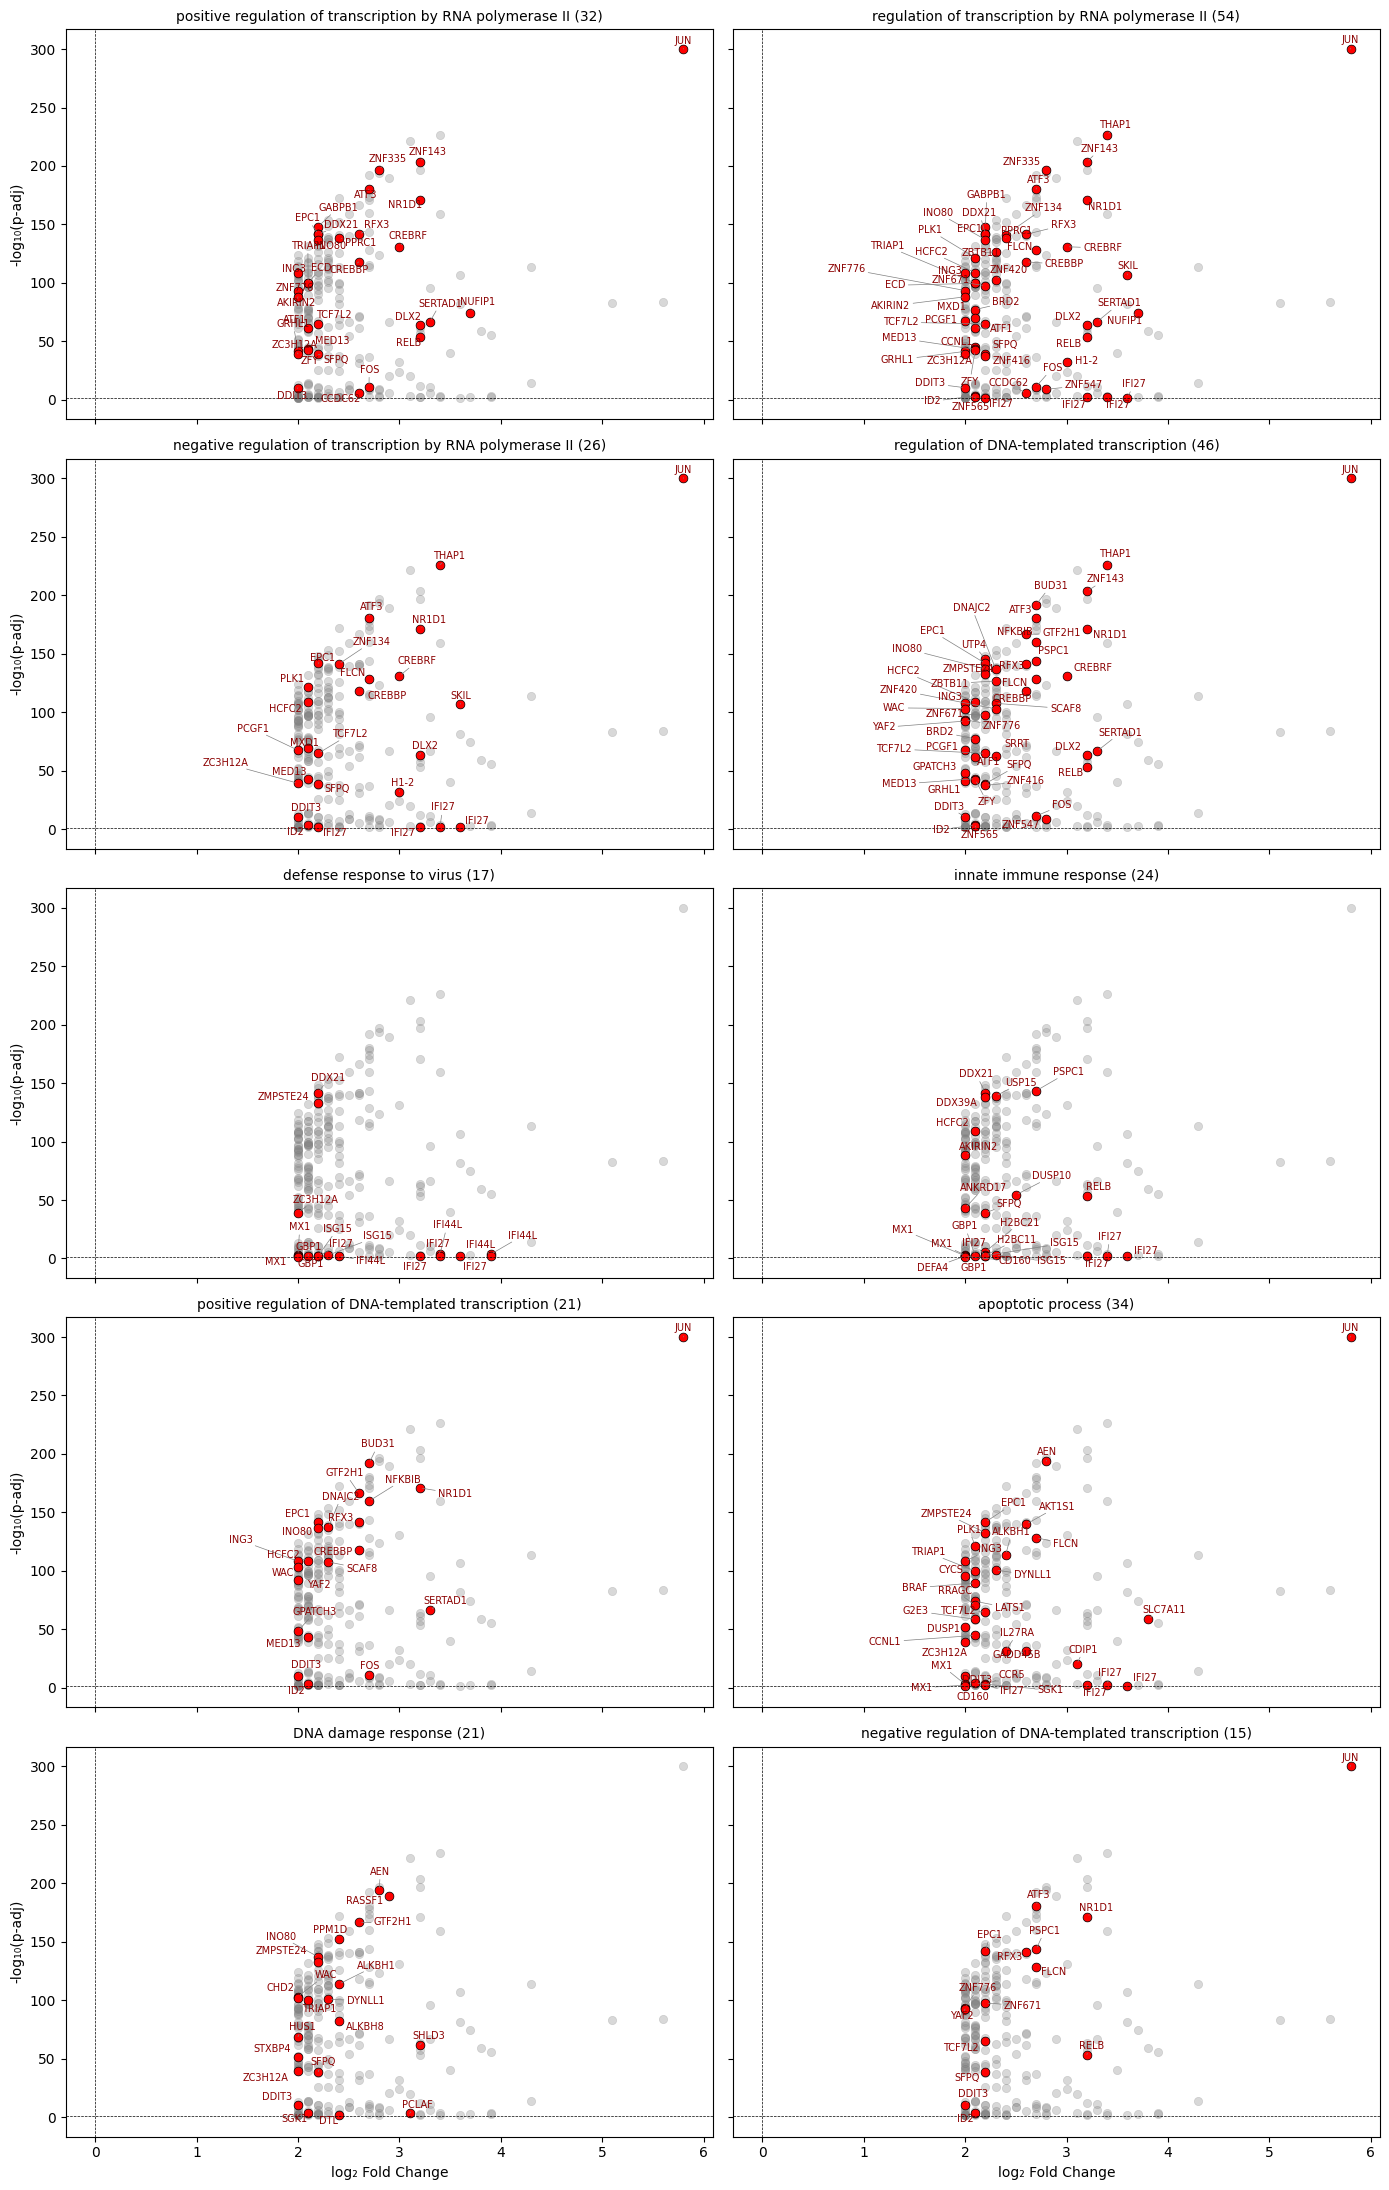

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from adjustText import adjust_text

# Filtrar genes sobre-expresados
df_up = final_df[final_df['Significativo'] == 'Sobre-expresado'].copy()

# Reemplazar p-vals 0 para el plot
eps = 1e-300
df_up['Adjusted_p_plot'] = df_up['Adjusted p-value'].replace(0, eps)
df_up['neglogp'] = -np.log10(df_up['Adjusted_p_plot'])

# Top 10 términos GO (usando tu top_terms)
top_go_terms = top_terms.index.tolist()

fig, axes = plt.subplots(5, 2, figsize=(14, 22), sharex=True, sharey=True)
axes = axes.flatten()

for i, go_term in enumerate(top_go_terms):
    ax = axes[i]
    # Todos genes sobre-expresados en gris
    sns.scatterplot(
        data=df_up,
        x='log_2 fold change',
        y='neglogp',
        color='grey',
        alpha=0.3,
        edgecolor=None,
        ax=ax
    )
    
    # Filtrar genes que tienen ese término GO (usamos str.contains)
    mask = df_up['Biological_Process'].str.contains(go_term, na=False)
    df_go = df_up[mask]
    
    # Genes resaltados en rojo
    sns.scatterplot(
        data=df_go,
        x='log_2 fold change',
        y='neglogp',
        color='red',
        edgecolor='black',
        s=40,
        ax=ax
    )
    
    # Etiquetas para esos genes (usar 'symbol')
    texts = []
    for _, row in df_go.iterrows():
        x, y = row['log_2 fold change'], row['neglogp']
        label = row['symbol'] if pd.notna(row['symbol']) else row['Gene']
        texts.append(ax.text(x, y, label, fontsize=7, ha='right', color='darkred'))
    
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))
    
    ax.set_title(f"{go_term} ({len(df_go)})", fontsize=10)
    ax.axhline(-np.log10(0.05), ls='--', color='black', linewidth=0.5)
    ax.axvline(0, ls='--', color='black', linewidth=0.5)
    ax.set_xlabel('log₂ Fold Change')
    ax.set_ylabel('-log₁₀(p-adj)')

plt.tight_layout()
plt.show()


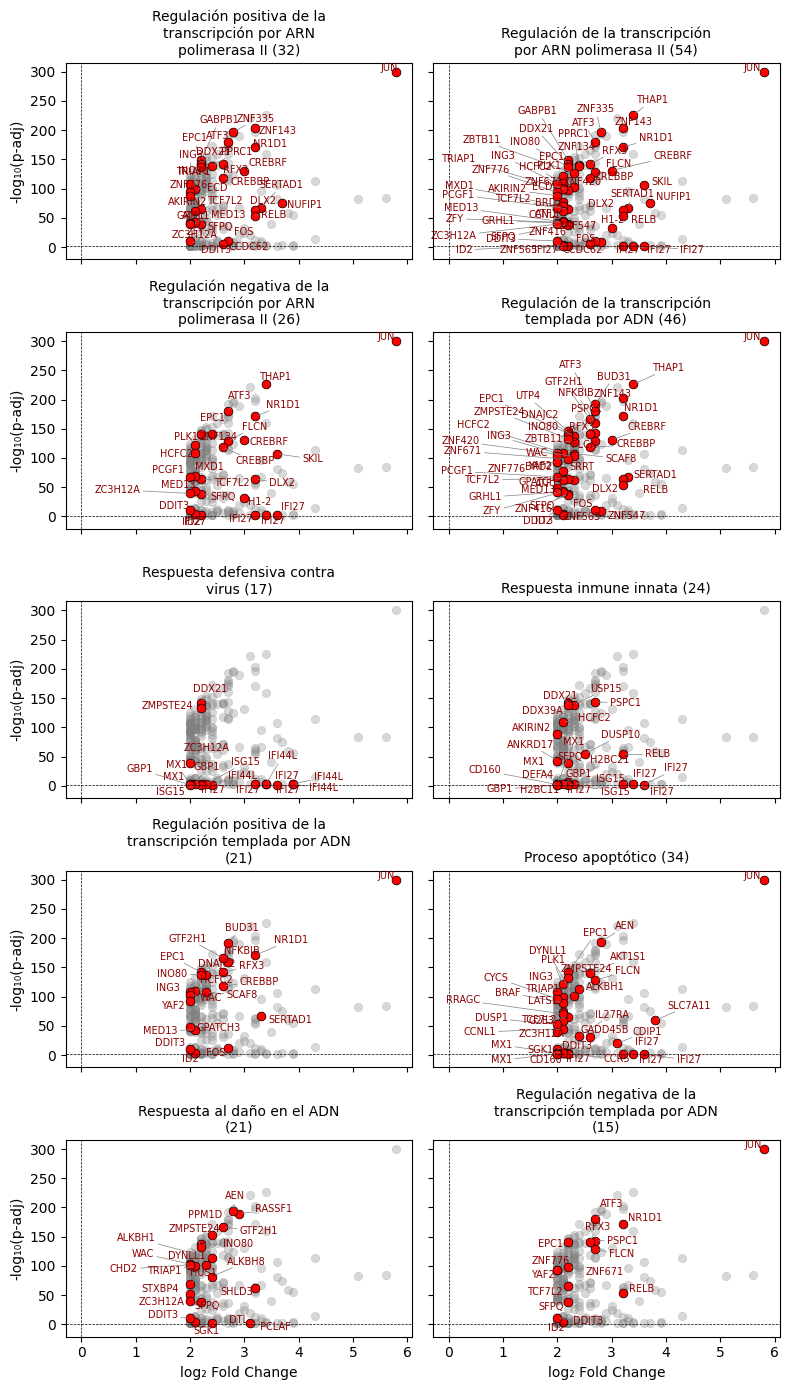

In [172]:
import textwrap


# Traducciones de los términos GO al español (ordenados igual que top_terms)
go_terms_es = [
    "Regulación positiva de la transcripción por ARN polimerasa II",
    "Regulación de la transcripción por ARN polimerasa II",
    "Regulación negativa de la transcripción por ARN polimerasa II",
    "Regulación de la transcripción templada por ADN",
    "Respuesta defensiva contra virus",
    "Respuesta inmune innata",
    "Regulación positiva de la transcripción templada por ADN",
    "Proceso apoptótico",
    "Respuesta al daño en el ADN",
    "Regulación negativa de la transcripción templada por ADN"
]

fig, axes = plt.subplots(5, 2, figsize=(8, 14), sharex=True, sharey=True)
axes = axes.flatten()

for i, go_term in enumerate(top_go_terms):
    ax = axes[i]
    
    # Todos genes sobre-expresados en gris
    sns.scatterplot(
        data=df_up,
        x='log_2 fold change',
        y='neglogp',
        color='grey',
        alpha=0.3,
        edgecolor=None,
        ax=ax
    )
    
    # Filtrar genes que tienen ese término GO (en inglés, porque así están en el DF)
    mask = df_up['Biological_Process'].str.contains(go_term, na=False)
    df_go = df_up[mask]
    
    # Genes resaltados en rojo
    sns.scatterplot(
        data=df_go,
        x='log_2 fold change',
        y='neglogp',
        color='red',
        edgecolor='black',
        s=40,
        ax=ax
    )
    
    # Etiquetas para esos genes
    texts = []
    for _, row in df_go.iterrows():
        x, y = row['log_2 fold change'], row['neglogp']
        label = row['symbol'] if pd.notna(row['symbol']) else row['Gene']
        texts.append(ax.text(x, y, label, fontsize=7, ha='right', color='darkred'))
    
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))
    
    # ✅ Ahora título en español
    titulo = f"{go_terms_es[i]} ({len(df_go)})"
    titulo_envuelto = "\n".join(textwrap.wrap(titulo, width=30))  # ajusta '30' según el tamaño
    ax.set_title(titulo_envuelto, fontsize=10)    
    
    ax.axhline(-np.log10(0.05), ls='--', color='black', linewidth=0.5)
    ax.axvline(0, ls='--', color='black', linewidth=0.5)
    ax.set_xlabel('log₂ Fold Change')
    ax.set_ylabel('-log₁₀(p-adj)')

plt.tight_layout()
plt.show()


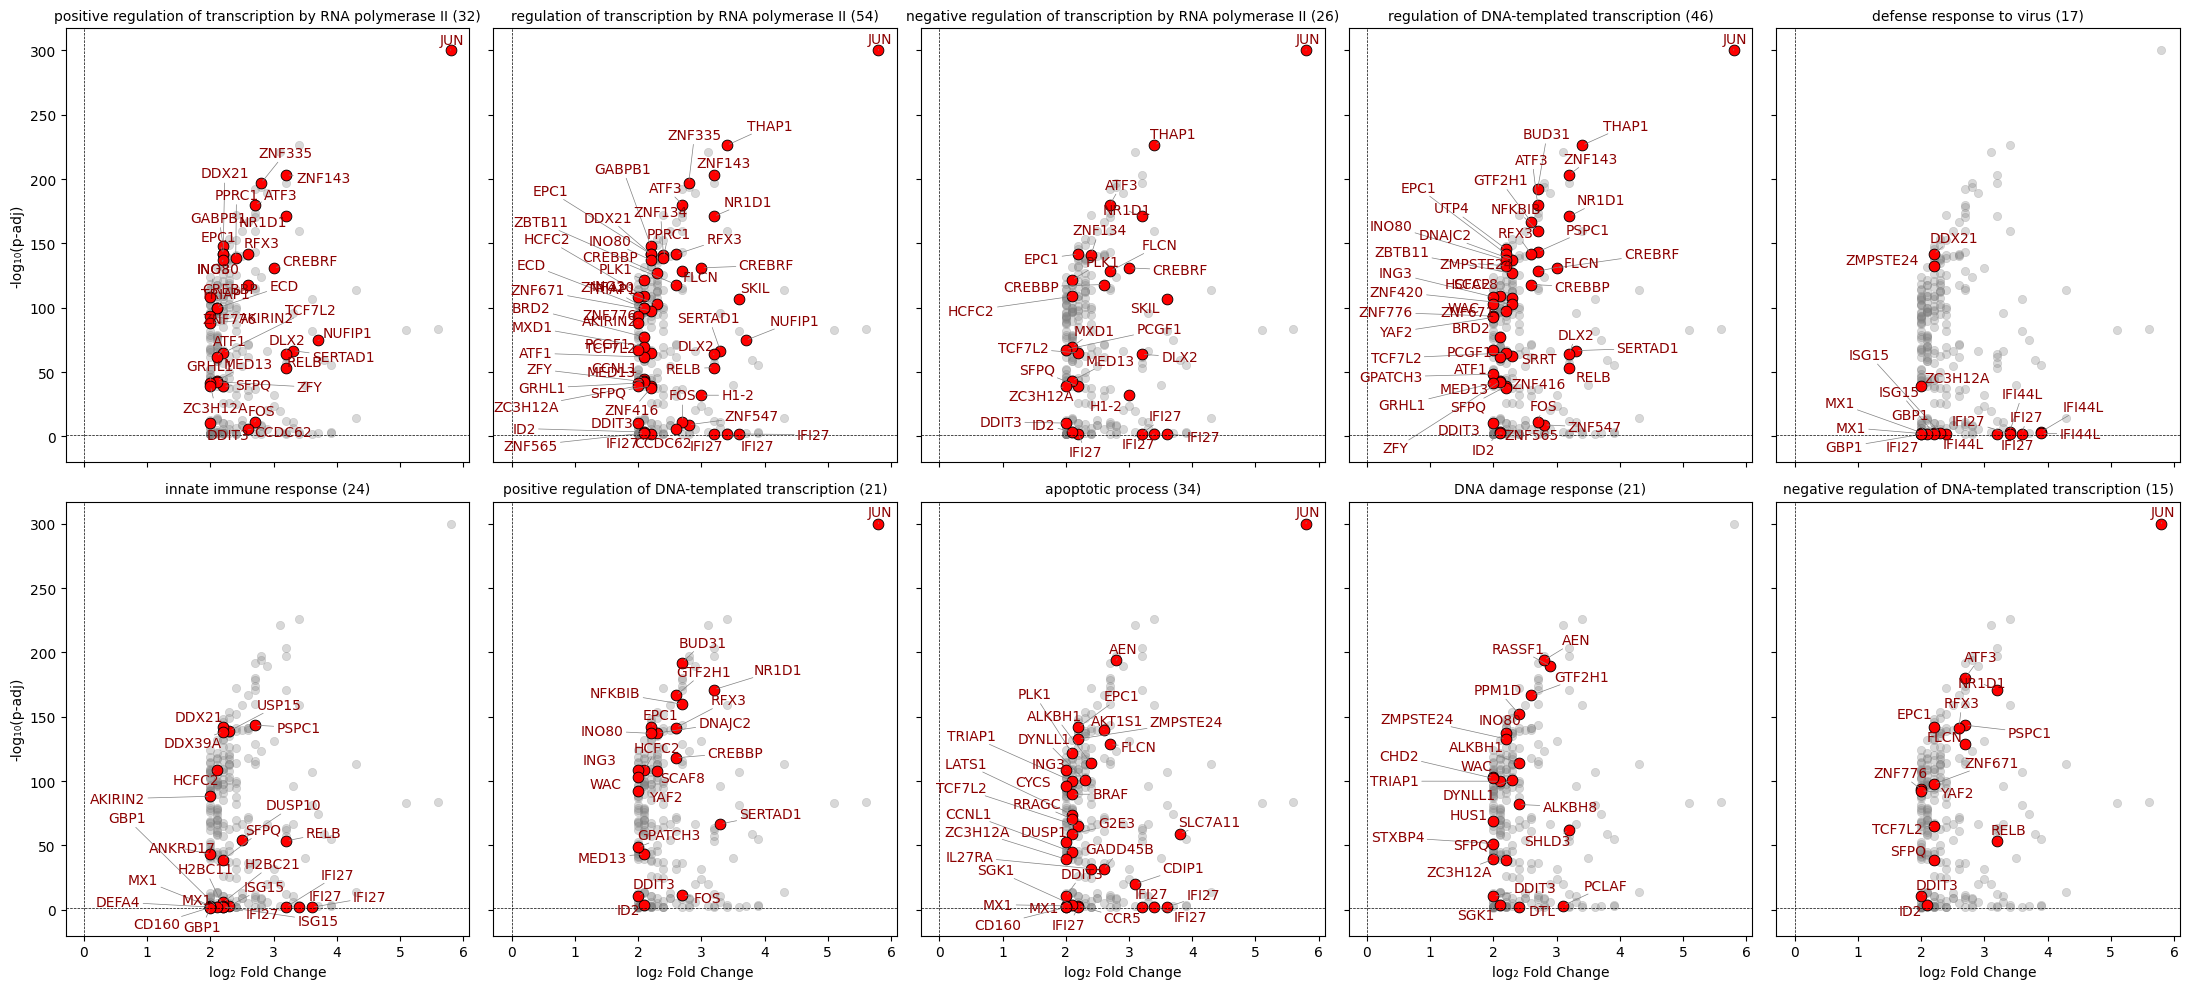

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from adjustText import adjust_text

# Filtrar genes sobre-expresados
df_up = final_df[final_df['Significativo'] == 'Sobre-expresado'].copy()

# Reemplazar p-vals 0 para el plot
eps = 1e-300
df_up['Adjusted_p_plot'] = df_up['Adjusted p-value'].replace(0, eps)
df_up['neglogp'] = -np.log10(df_up['Adjusted_p_plot'])

# Top 10 términos GO (usando tu top_terms)
top_go_terms = top_terms.index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(22, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, go_term in enumerate(top_go_terms):
    ax = axes[i]
    # Todos genes sobre-expresados en gris
    sns.scatterplot(
        data=df_up,
        x='log_2 fold change',
        y='neglogp',
        color='grey',
        alpha=0.3,
        edgecolor=None,
        ax=ax
    )
    
    # Filtrar genes que tienen ese término GO (usamos str.contains)
    mask = df_up['Biological_Process'].str.contains(go_term, na=False)
    df_go = df_up[mask]
    
    # Genes resaltados en rojo
    sns.scatterplot(
        data=df_go,
        x='log_2 fold change',
        y='neglogp',
        color='red',
        edgecolor='black',
        s=60,
        ax=ax
    )
    
    # Etiquetas para esos genes (usar 'symbol')
    texts = []
    for _, row in df_go.iterrows():
        x, y = row['log_2 fold change'], row['neglogp']
        label = row['symbol'] if pd.notna(row['symbol']) else row['Gene']
        texts.append(ax.text(x, y, label, fontsize=10, ha='right', color='darkred'))
    
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))
    
    ax.set_title(f"{go_term} ({len(df_go)})", fontsize=10)
    ax.axhline(-np.log10(0.05), ls='--', color='black', linewidth=0.5)
    ax.axvline(0, ls='--', color='black', linewidth=0.5)
    ax.set_xlabel('log₂ Fold Change')
    ax.set_ylabel('-log₁₀(p-adj)')

plt.tight_layout()
plt.show()


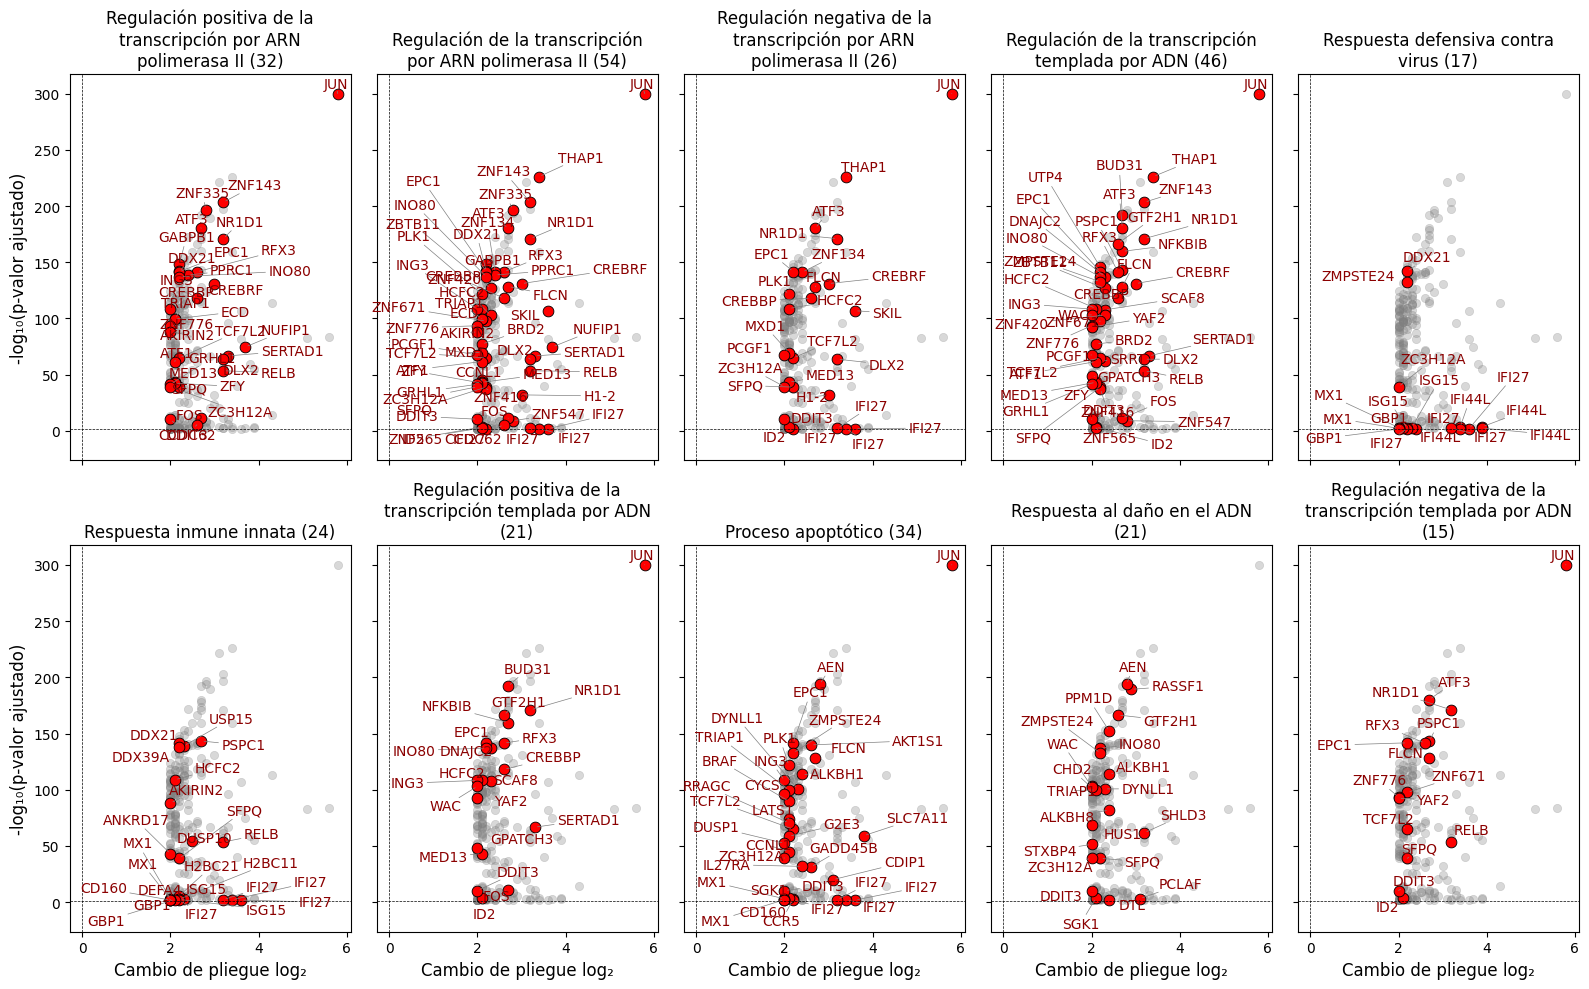

In [169]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from adjustText import adjust_text

# Filtrar genes sobre-expresados
df_up = final_df[final_df['Significativo'] == 'Sobre-expresado'].copy()

# Reemplazar p-vals 0 para el plot
eps = 1e-300
df_up['Adjusted_p_plot'] = df_up['Adjusted p-value'].replace(0, eps)
df_up['neglogp'] = -np.log10(df_up['Adjusted_p_plot'])

# Top 10 términos GO (usando tu top_terms en inglés para filtrar)
top_go_terms = top_terms.index.tolist()

# Traducción manual al español en el mismo orden que top_go_terms
go_terms_es = [
    "Regulación positiva de la transcripción por ARN polimerasa II",
    "Regulación de la transcripción por ARN polimerasa II",
    "Regulación negativa de la transcripción por ARN polimerasa II",
    "Regulación de la transcripción templada por ADN",
    "Respuesta defensiva contra virus",
    "Respuesta inmune innata",
    "Regulación positiva de la transcripción templada por ADN",
    "Proceso apoptótico",
    "Respuesta al daño en el ADN",
    "Regulación negativa de la transcripción templada por ADN"
]

fig, axes = plt.subplots(2, 5, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, go_term in enumerate(top_go_terms):
    ax = axes[i]
    
    # Todos genes sobre-expresados en gris
    sns.scatterplot(
        data=df_up,
        x='log_2 fold change',
        y='neglogp',
        color='grey',
        alpha=0.3,
        edgecolor=None,
        ax=ax
    )
    
    # Filtrar genes que tienen ese término GO (usamos el nombre en inglés para el filtrado)
    mask = df_up['Biological_Process'].str.contains(go_term, na=False)
    df_go = df_up[mask]
    
    # Genes resaltados en rojo
    sns.scatterplot(
        data=df_go,
        x='log_2 fold change',
        y='neglogp',
        color='red',
        edgecolor='black',
        s=60,
        ax=ax
    )
    
    # Etiquetas de los genes
    texts = []
    for _, row in df_go.iterrows():
        x, y = row['log_2 fold change'], row['neglogp']
        label = row['symbol'] if pd.notna(row['symbol']) else row['Gene']
        texts.append(ax.text(x, y, label, fontsize=10, ha='right', color='darkred'))
    
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))
    
    # ✅ Título en español
    titulo = f"{go_terms_es[i]} ({len(df_go)})"
    titulo_envuelto = "\n".join(textwrap.wrap(titulo, width=30))  # ajusta '30' según el tamaño
    ax.set_title(titulo_envuelto, fontsize=12)        

    ax.axhline(-np.log10(0.05), ls='--', color='black', linewidth=0.5)
    ax.axvline(0, ls='--', color='black', linewidth=0.5)
    
    # ✅ Ejes en español
    ax.set_xlabel('Cambio de pliegue log₂', fontsize=12)
    ax.set_ylabel('-log₁₀(p-valor ajustado)', fontsize=12)

plt.tight_layout()
plt.show()


In [136]:
final_df

,Gene,Species,log_2 fold change,Adjusted p-value,Significativo,Adjusted_p_plot,neglogp,symbol,name,Biological_Process,Molecular_Function,Cellular_Component
0,ENSG00000177606,homo sapiens,5.8,0.000000e+00,Sobre-expresado,1.000000e-300,300.000000,JUN,"Jun proto-oncogene, AP-1 transcription factor ...",negative regulation of transcription by RNA po...,transcription cis-regulatory region binding (G...,nuclear chromosome (GO:0000228); chromatin (GO...
1,ENSG00000164309,homo sapiens,5.6,1.625288e-84,Sobre-expresado,1.625288e-84,83.789070,CMYA5,cardiomyopathy associated 5,,,nucleus (GO:0005634); nucleus (GO:0005634); cy...
2,ENSG00000184545,homo sapiens,5.1,1.509396e-83,Sobre-expresado,1.509396e-83,82.821197,DUSP8,dual specificity phosphatase 8,signal transduction (GO:0007165); dephosphoryl...,phosphoprotein phosphatase activity (GO:000472...,nucleus (GO:0005634); cytoplasm (GO:0005737); ...
3,ENSG00000085465,homo sapiens,4.3,2.881886e-114,Sobre-expresado,2.881886e-114,113.540323,OVGP1,oviductal glycoprotein 1,carbohydrate metabolic process (GO:0005975); c...,chitinase activity (GO:0004568); chitin bindin...,extracellular region (GO:0005576); cytosol (GO...
4,ENSG00000087589,homo sapiens,4.3,7.197535e-15,Sobre-expresado,7.197535e-15,14.142816,CASS4,Cas scaffold protein family member 4,cell adhesion (GO:0007155); cell surface recep...,protein binding (GO:0005515); protein tyrosine...,cytoplasm (GO:0005737); cytoplasm (GO:0005737)...
...,...,...,...,...,...,...,...,...,...,...,...,...
260,ENSG00000276966,homo sapiens,2.0,8.746922e-03,Sobre-expresado,8.746922e-03,2.058145,H4C5,H4 clustered histone 5,chromatin organization (GO:0006325); nucleosom...,DNA binding (GO:0003677); DNA binding (GO:0003...,"chromosome, telomeric region (GO:0000781); nuc..."
261,ENSG00000126787,homo sapiens,2.0,1.026658e-02,Sobre-expresado,1.026658e-02,1.988574,DLGAP5,DLG associated protein 5,mitotic spindle organization (GO:0007052); chr...,protein binding (GO:0005515); microtubule bind...,nucleus (GO:0005634); nucleus (GO:0005634); nu...
262,ENSG00000064886,homo sapiens,2.0,1.414406e-02,Sobre-expresado,1.414406e-02,1.849426,CHI3L2,chitinase 3 like 2,carbohydrate metabolic process (GO:0005975); c...,chitinase activity (GO:0004568); chitinase act...,extracellular region (GO:0005576); extracellul...
263,ENSG00000117281,homo sapiens,2.0,1.448692e-02,Sobre-expresado,1.448692e-02,1.839024,CD160,CD160 molecule,angiogenesis (GO:0001525); positive regulation...,transmembrane signaling receptor activity (GO:...,extracellular region (GO:0005576); plasma memb...
